<a href="https://colab.research.google.com/github/thiagola92/pucpos-qualidade/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
%pip install ipykernel matplotlib numpy pandas scikit-learn seaborn requests

In [12]:
import pandas
import pickle
import seaborn
import requests
from pathlib import Path
from zipfile import ZipFile
from matplotlib import pyplot
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

In [18]:
if not Path("dataset.csv").exists():
    if not Path("dataset.zip").exists():
        response = requests.get("https://github.com/thiagola92/pucpos-qualidade/raw/refs/heads/main/backend/machine_learning/dataset.zip")
        assert response.status_code == 200, "Failed to get CSV from Github"
        Path("dataset.zip").write_bytes(response.content)

    ZipFile("dataset.zip").extract("dataset.csv")

dataset = pandas.read_csv("dataset.csv")

pandas.set_option("display.max_columns", None)
pandas.set_option('display.max_colwidth', None)
dataset.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µà¹‰ à¸‚à¹ˆà¸²à¸§à¸à¸µà¸¬à¸² à¸‚à¹ˆà¸²à¸§à¸šà¸±à¸™à¹€à¸—à¸´à¸‡ à¸­à¸±à¸žà¹€à¸”à¸—à¸ªà¸”à¹ƒà¸«à¸¡à¹ˆà¸—à¸¸à¸à¸§à¸±à¸™ &#8211; à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸à¸µà¸¬à¸² à¸‚à¹ˆà¸²à¸§à¸šà¸±à¸™à¹€à¸—à¸´à¸‡ à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µà¹‰ à¸­à¸±à¸›à¹€à¸”à¸•à¸‚à¹ˆà¸²à¸§à¸ªà¸²à¸£à¸£à¸§à¸”à¹€à¸£à¹‡à¸§à¸—à¸±à¸™à¹ƒà¸ˆ à¸žà¸£à¹‰à¸­à¸¡à¸£à¸±à¸šà¸Šà¸¡à¸ªà¸²à¸£à¸°à¸™à¹ˆà¸²à¸£à¸¹à¹‰à¸•à¹ˆà¸²à¸‡à¹† à¹„à¸”à¹‰à¸Ÿà¸£à¸µà¸•à¸¥à¸­à¸” 24à¸Šà¸±à¹ˆà¸§à¹‚à¸¡à¸‡,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medicine,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


In [19]:
# Drop all columns that are strings and that I can't reproduce the result.
dataset0 = dataset.drop(columns=["FILENAME", "URL", "Domain", "TLD", "Title", "URLSimilarityIndex", "CharContinuationRate", "TLDLegitimateProb", "URLCharProb"])

# Drop columns that needs robots.txt.
dataset1 = dataset0.drop(columns=["Robots"])

# Drop columns that needs HAR file.
dataset2 = dataset1.drop(columns=["NoOfURLRedirect", "NoOfSelfRedirect"])

# Drop columns that need page content.
dataset3 = dataset2.drop(columns=[
    "LineOfCode",
    "LargestLineLength",
    "HasTitle",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "HasFavicon",
    "IsResponsive",
    "HasDescription",
    "NoOfPopup",
    "NoOfiFrame",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef",
])

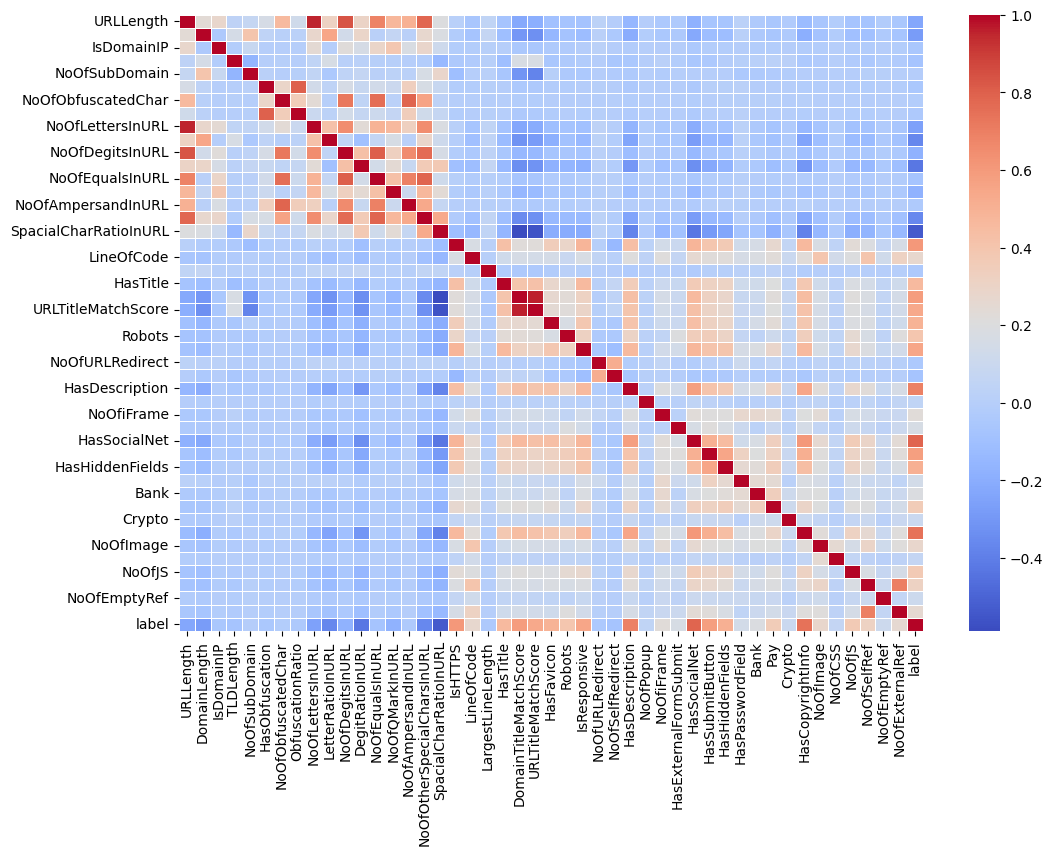

In [20]:
pyplot.figure(figsize=(12,8))
seaborn.heatmap(dataset0.corr('pearson'), annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
pyplot.show()

In [21]:
seed = 7
kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=seed
)

# Classifiers.
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
random_forest = ('RF', RandomForestClassifier())
svm = ('SVM', SVC())

# Transformers.
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Pipelines.
pipelines = [
    # Dataset original.
    ('orig-KNN', Pipeline([knn])),
    ('orig-CART', Pipeline([cart])),
    ('orig-NB', Pipeline([naive_bayes])),
    ('orig-RF', Pipeline([random_forest])),
    # ('SVM-orig', Pipeline([svm])),

    # Dataset standarized.
    ('stand-KNN', Pipeline([standard_scaler, knn])),
    ('stand-CART', Pipeline([standard_scaler, cart])),
    ('stand-NB', Pipeline([standard_scaler, naive_bayes])),
    ('stand-RF', Pipeline([standard_scaler, random_forest])),
    # ('SVM-padr', Pipeline([standard_scaler, svm])),

    # Dataset normalized.
    ('norm-KNN', Pipeline([min_max_scaler, knn])),
    ('norm-CART', Pipeline([min_max_scaler, cart])),
    ('norm-NB', Pipeline([min_max_scaler, naive_bayes])),
    ('norm-RF', Pipeline([min_max_scaler, random_forest])),
    # ('SVM-norm', Pipeline([min_max_scaler, svm])),
]

In [22]:
def analyze_dataset(dataset):
    X = dataset.drop(columns=["label"])
    y = dataset["label"]

    # Split dataset between training and tests (but we are ignoring tests right now).
    X_train, _, y_train, _ = train_test_split(
        X, y,
        test_size=0.20,
        shuffle=True,
        random_state=seed,
        stratify=y
    )

    results = []

    # Check the result when training with X_train and y_train.
    for name, model in pipelines:
        cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')

        results.append((name, model, cv_results))

        print("%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()))

    # Plot boxplots.
    figure = pyplot.figure(figsize=(25,10))
    axes = figure.add_subplot(111)

    pyplot.boxplot([r[2] for r in results])
    axes.set_xticklabels([r[0] for r in results])
    pyplot.show()

    # Get the best score.
    best = (None, None)
    best_scoring = 0

    for name, model, cv_results in results:
        if cv_results.mean() > best_scoring:
            best_scoring = cv_results.mean()
            best = (name, model)

    return best

=== Full dataset
orig-KNN: 0.994 (0.001)
orig-CART: 0.999 (0.000)
orig-NB: 0.971 (0.003)
orig-RF: 1.000 (0.000)
stand-KNN: 0.998 (0.000)
stand-CART: 0.999 (0.000)
stand-NB: 0.936 (0.002)
stand-RF: 1.000 (0.000)
norm-KNN: 0.994 (0.001)
norm-CART: 0.999 (0.000)
norm-NB: 0.954 (0.002)
norm-RF: 1.000 (0.000)


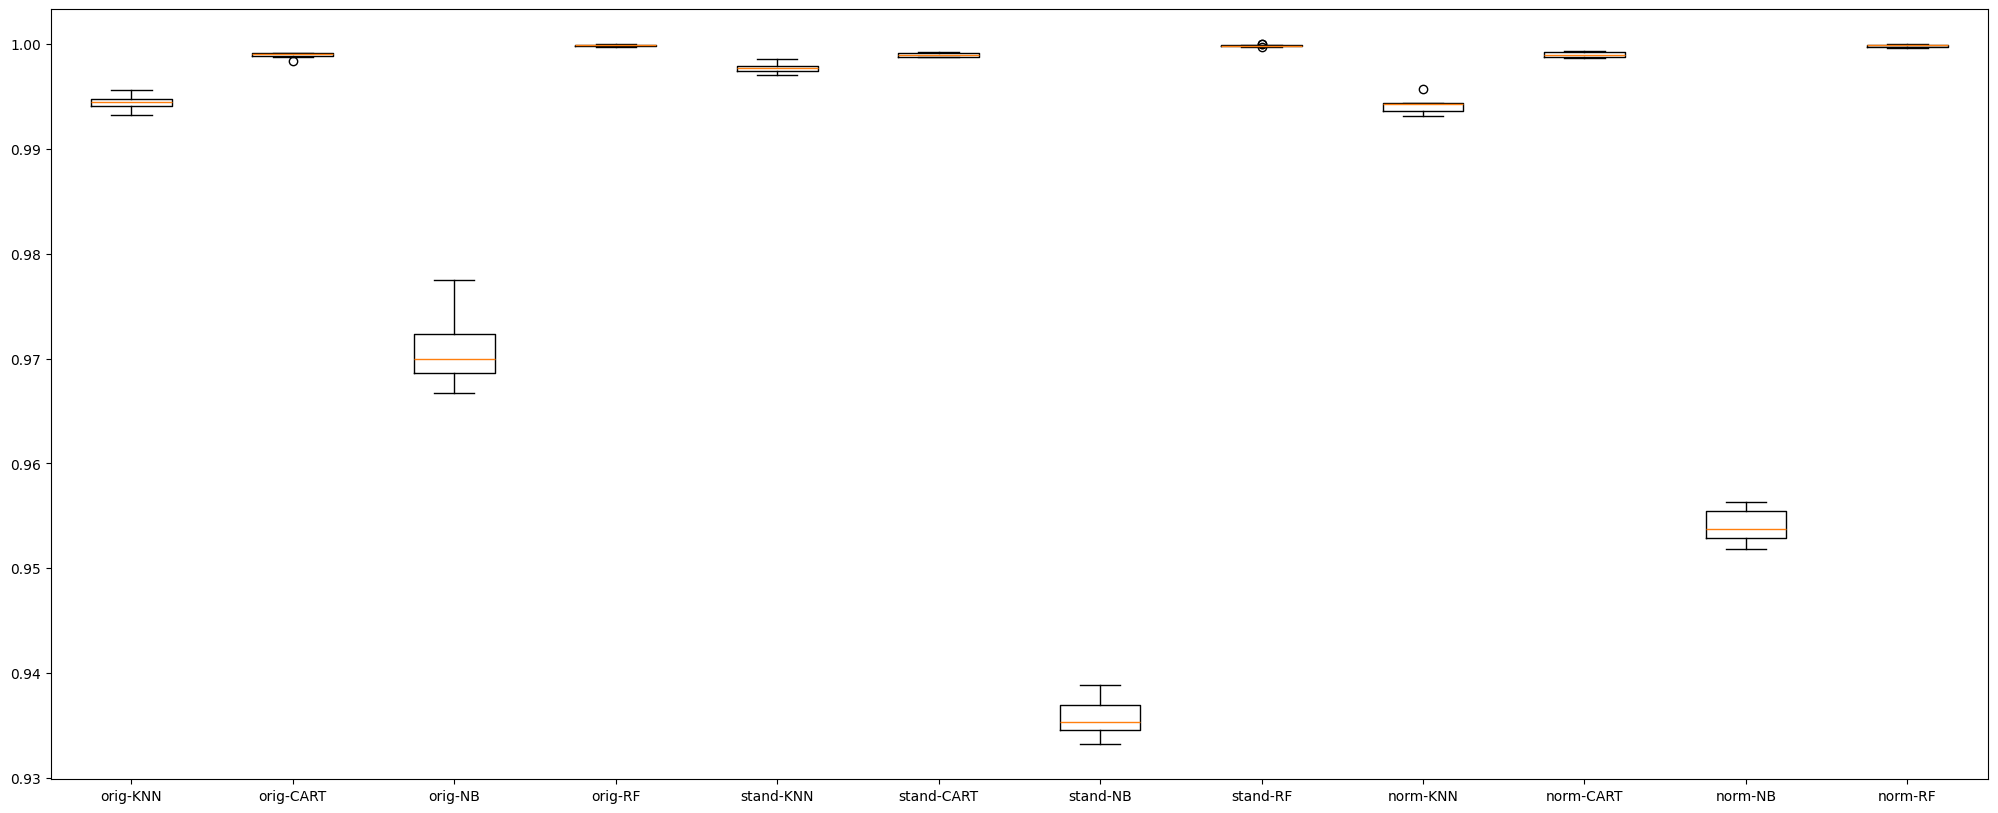

=== Without robots.txt details
orig-KNN: 0.994 (0.001)
orig-CART: 0.999 (0.000)
orig-NB: 0.971 (0.003)
orig-RF: 1.000 (0.000)
stand-KNN: 0.998 (0.000)
stand-CART: 0.999 (0.000)
stand-NB: 0.936 (0.002)
stand-RF: 1.000 (0.000)
norm-KNN: 0.995 (0.001)
norm-CART: 0.999 (0.000)
norm-NB: 0.954 (0.002)
norm-RF: 1.000 (0.000)


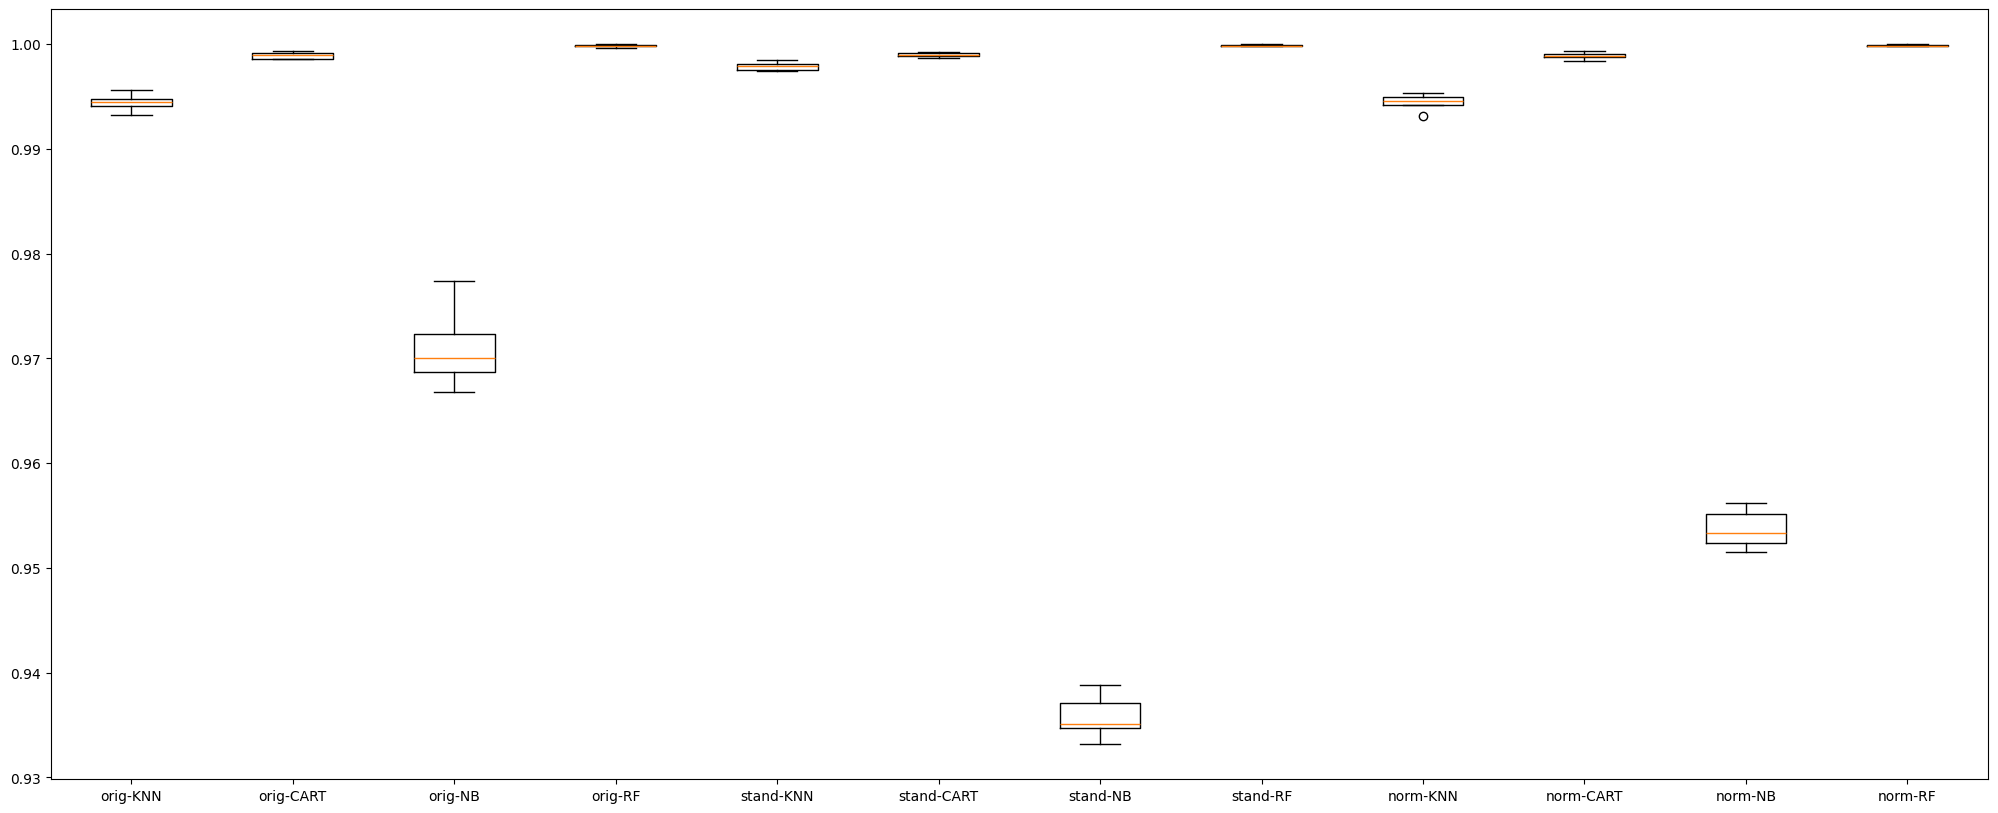

=== Without HAR file details
orig-KNN: 0.994 (0.001)
orig-CART: 0.999 (0.000)
orig-NB: 0.971 (0.003)
orig-RF: 1.000 (0.000)
stand-KNN: 0.998 (0.000)
stand-CART: 0.999 (0.000)
stand-NB: 0.936 (0.002)
stand-RF: 1.000 (0.000)
norm-KNN: 0.995 (0.000)
norm-CART: 0.999 (0.000)
norm-NB: 0.954 (0.002)
norm-RF: 1.000 (0.000)


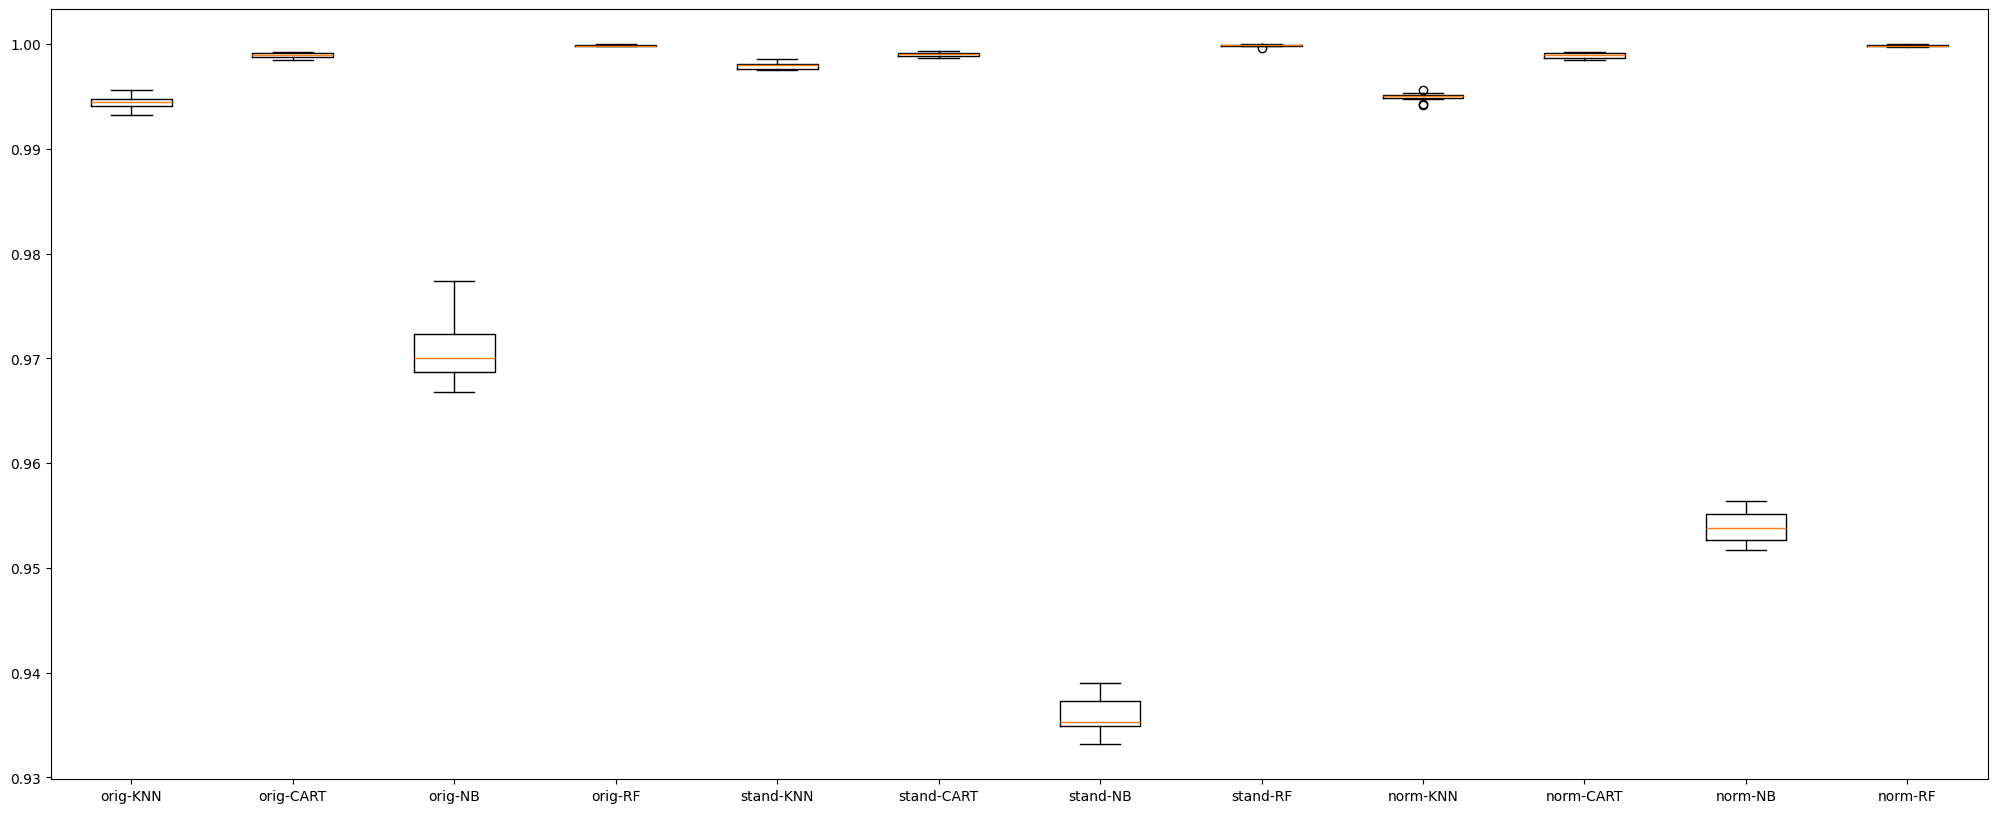

=== Without page content details
orig-KNN: 0.996 (0.001)
orig-CART: 0.997 (0.000)
orig-NB: 0.919 (0.002)
orig-RF: 0.997 (0.000)
stand-KNN: 0.997 (0.000)
stand-CART: 0.997 (0.000)
stand-NB: 0.898 (0.002)
stand-RF: 0.997 (0.000)
norm-KNN: 0.997 (0.000)
norm-CART: 0.997 (0.000)
norm-NB: 0.905 (0.003)
norm-RF: 0.997 (0.000)


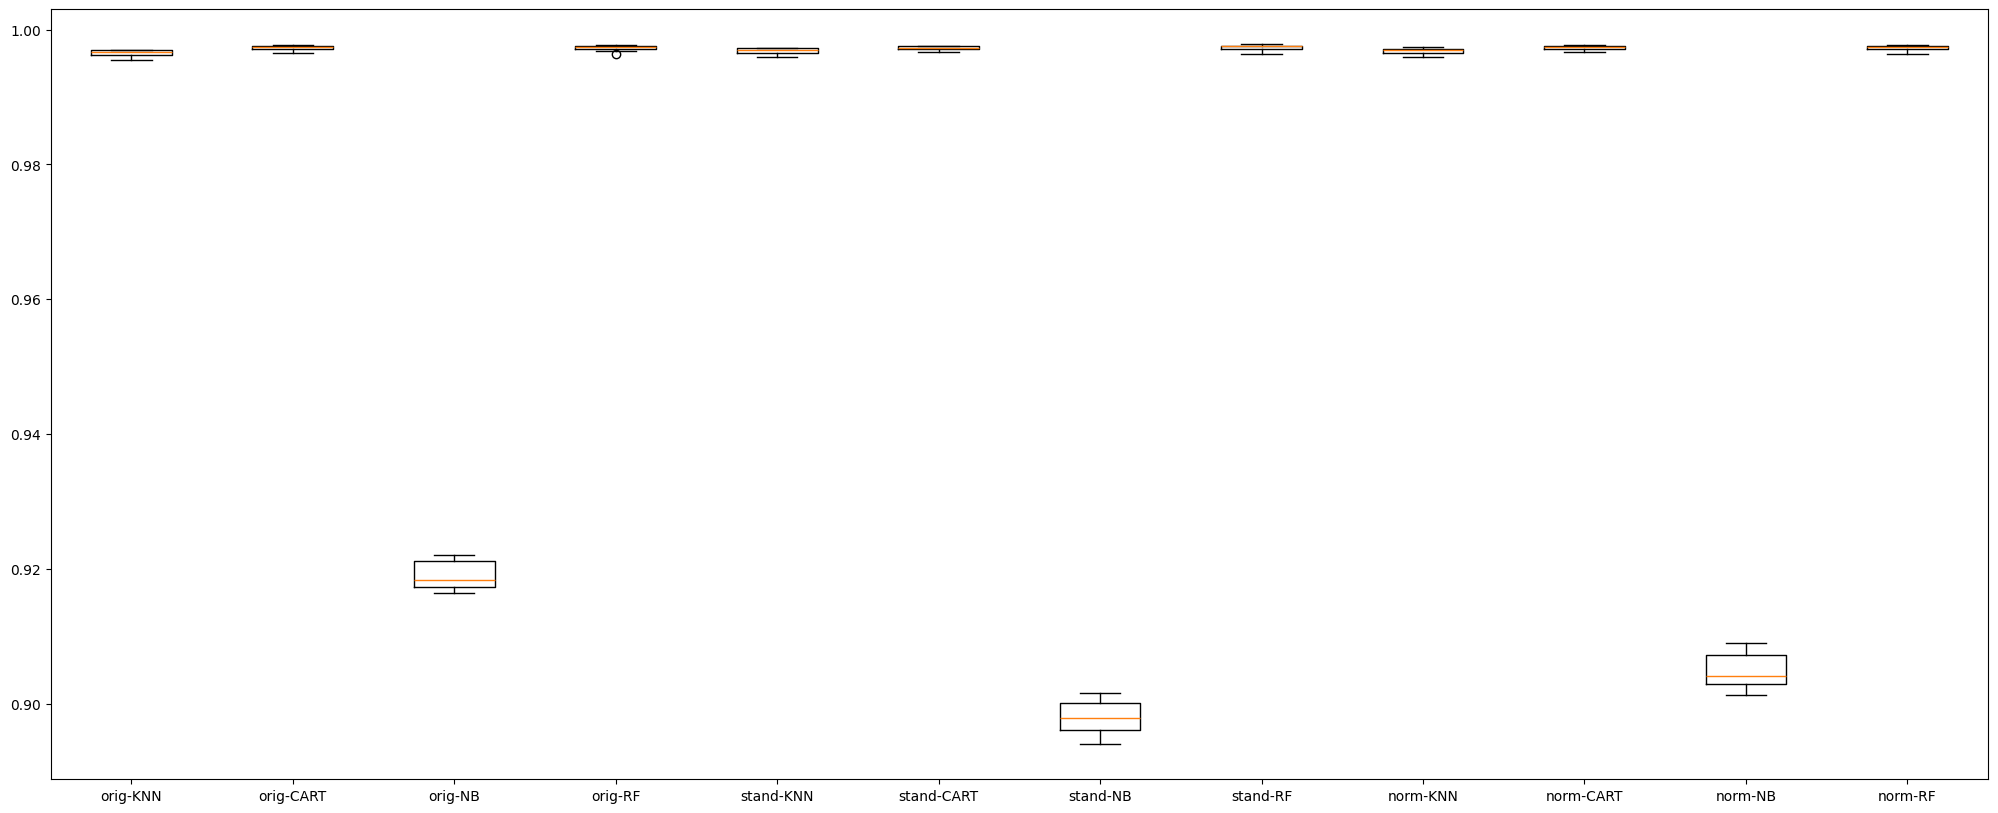

In [23]:
print("=== Full dataset")
best0 = analyze_dataset(dataset0)

print("=== Without robots.txt details")
best1 = analyze_dataset(dataset1)

print("=== Without HAR file details")
best2 = analyze_dataset(dataset2)

print("=== Without page content details")
best3 = analyze_dataset(dataset3)

In [24]:
def test_prediction(dataset, model):
    X = dataset.drop(columns=["label"])
    y = dataset["label"]

    # Split dataset between training and tests.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        shuffle=True,
        random_state=seed,
        stratify=y
    )

    # Test predictions.
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print(accuracy_score(y_test, predictions))

In [25]:
print("=== Full dataset (%s)" % best0[0])
test_prediction(dataset0, best0[1])

print("=== Without robots.txt details (%s)" % best1[0])
test_prediction(dataset1, best1[1])

print("=== Without HAR file details (%s)" % best2[0])
test_prediction(dataset2, best2[1])

print("=== Without page content details (%s)" % best3[0])
test_prediction(dataset3, best3[1])

=== Full dataset (orig-RF)
0.9998303611187684
=== Without robots.txt details (stand-RF)
0.9998727708390763
=== Without HAR file details (orig-RF)
0.9998727708390763
=== Without page content details (stand-RF)
0.9976038508026039


In [26]:
def save_model(dataset, model, output):
    X = dataset.drop(columns=["label"])
    y = dataset["label"]

    model = RandomForestClassifier()
    model.fit(X, y)

    with open(output, "wb") as f:
        pickle.dump(model, f)

In [27]:
save_model(dataset0, best0[1], "model0.pkl")
save_model(dataset1, best1[1], "model1.pkl")
save_model(dataset2, best2[1], "model2.pkl")
save_model(dataset3, best3[1], "model3.pkl")